# DevAscend — Exploratory Data Analysis (EDA)
Data: Stack Overflow Developer Survey 2021–2025, after `ingest.py` (→ Cassandra) and `clean.py` (→ `data/clean.parquet`).

Goal of EDA: understand the data **before** training, and make charts for the report.
Every chart is also saved to `notebooks/figures/`.

In [1]:
import sys; sys.path.insert(0, "..")
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from config import CLEAN_FILE, LEVELS
sns.set_theme(style="whitegrid")
FIG = Path("figures"); FIG.mkdir(exist_ok=True)
df = pd.read_parquet(CLEAN_FILE)
print(df.shape)
df.head()

(153645, 11)


,survey_year,response_id,years_code,years_pro,ed_level,role,country,skills,salary_usd,level_score,level
0,2021,10,7.0,4.0,5,Data/ML,Sweden,C++;Keras;NumPy;Pandas;PostgreSQL;PyTorch;Pyth...,51552.0,28.64,Junior
1,2021,12,12.0,5.0,4,Back-end,Spain,Amazon Web Services (AWS);Bash/Shell;Express;H...,46482.0,45.62,Mid
2,2021,13,15.0,6.0,5,Back-end,Germany,C;C++;Java;Perl;Qt;Ruby;Ruby on Rails,77290.0,53.96,Mid
3,2021,17,6.0,2.0,4,Full-stack,Turkey,.NET;ASP.NET Core;Amazon Web Services (AWS);An...,17748.0,20.62,Junior
4,2021,18,9.0,6.0,4,Full-stack,Canada,Amazon Web Services (AWS);Bash/Shell;HTML/CSS;...,46135.0,26.44,Junior


## 1. How many developers per survey year?

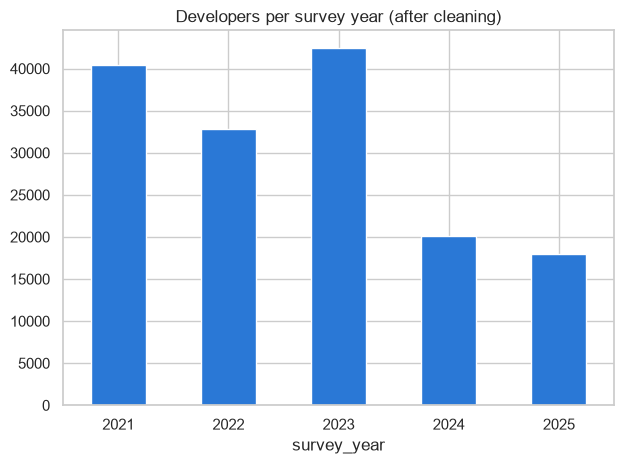

In [2]:
ax = df["survey_year"].value_counts().sort_index().plot.bar(rot=0, color="#2a78d6", title="Developers per survey year (after cleaning)")
plt.tight_layout(); plt.savefig(FIG / "rows_per_year.png", dpi=120); plt.show()

## 2. Salary distribution
Salaries are **right-skewed** (a few very high salaries). That's why Model B learns `log(salary)`.

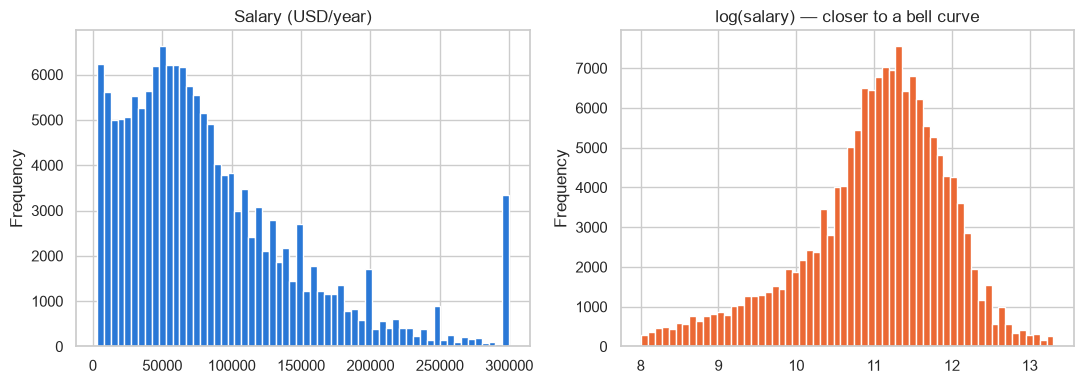

count    153645.0
mean      86528.0
std       73332.0
min        3000.0
25%       38388.0
50%       69608.0
75%      114180.0
max      600000.0
Name: salary_usd, dtype: float64

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df["salary_usd"].clip(upper=300_000).plot.hist(bins=60, ax=axes[0], color="#2a78d6", title="Salary (USD/year)")
np.log(df["salary_usd"]).plot.hist(bins=60, ax=axes[1], color="#eb6834", title="log(salary) — closer to a bell curve")
plt.tight_layout(); plt.savefig(FIG / "salary_distribution.png", dpi=120); plt.show()
df["salary_usd"].describe().round(0)

## 3. Experience vs salary
More professional experience → higher median salary (strong signal for both models).

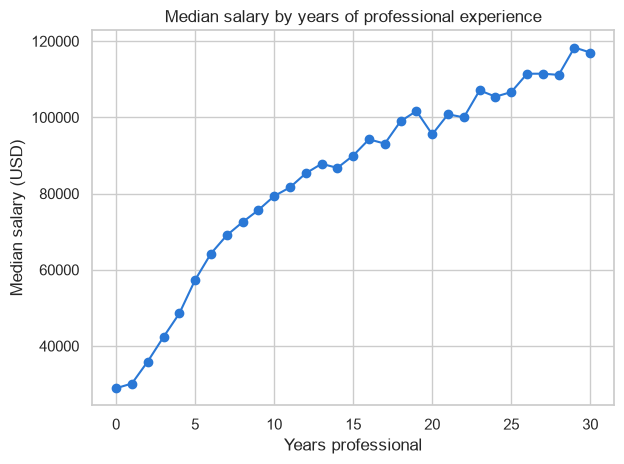

In [4]:
med = df.assign(yrs=df["years_pro"].clip(upper=30).round()).groupby("yrs")["salary_usd"].median()
ax = med.plot(marker="o", color="#2a78d6", title="Median salary by years of professional experience")
ax.set_xlabel("Years professional"); ax.set_ylabel("Median salary (USD)")
plt.tight_layout(); plt.savefig(FIG / "experience_vs_salary.png", dpi=120); plt.show()

## 4. Country matters a lot
Same job, very different pay → country is the most important feature for Model B.

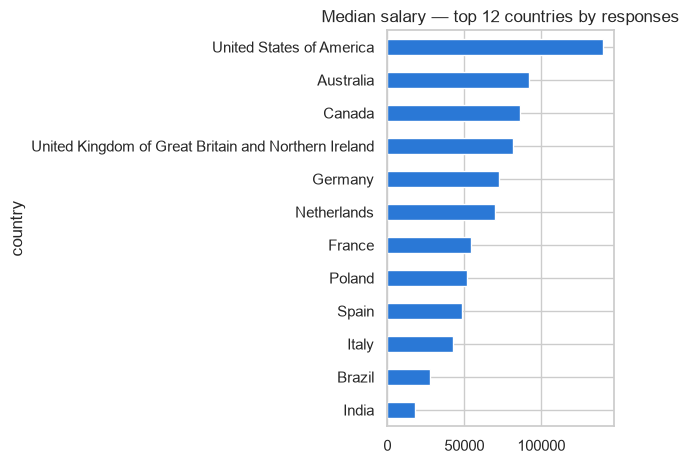

In [5]:
top = df["country"].value_counts().head(12).index
med = df[df["country"].isin(top)].groupby("country")["salary_usd"].median().sort_values()
ax = med.plot.barh(color="#2a78d6", title="Median salary — top 12 countries by responses")
plt.tight_layout(); plt.savefig(FIG / "salary_by_country.png", dpi=120); plt.show()

## 5. Roles

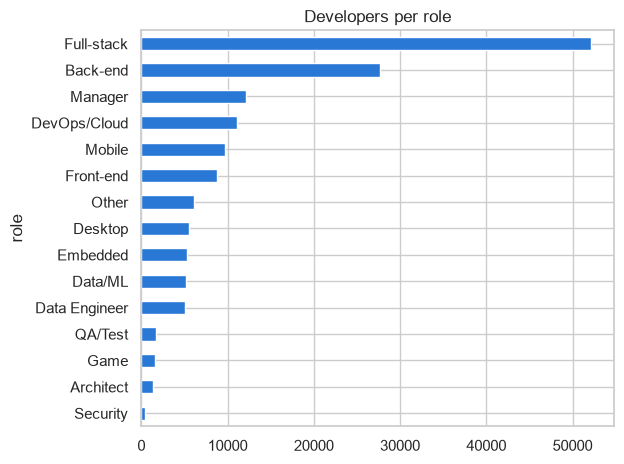

In [6]:
ax = df["role"].value_counts().sort_values().plot.barh(color="#2a78d6", title="Developers per role")
plt.tight_layout(); plt.savefig(FIG / "roles.png", dpi=120); plt.show()

## 6. Most common skills

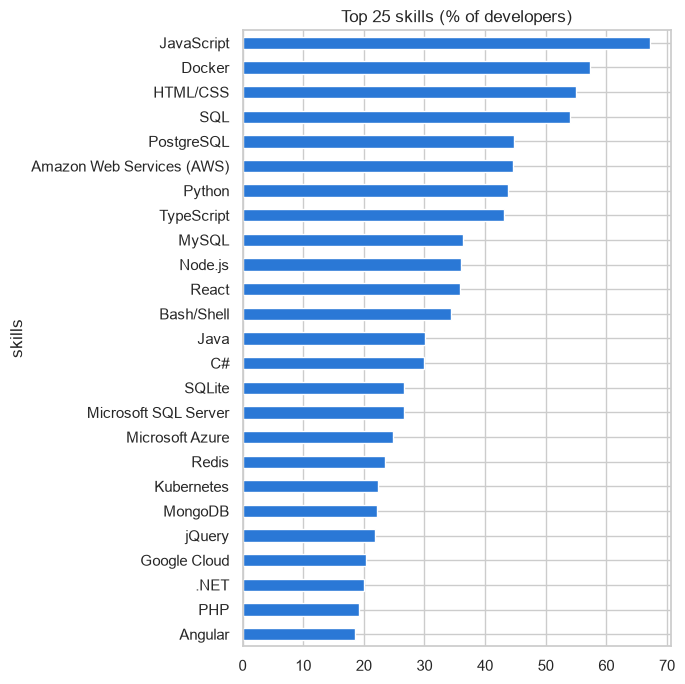

In [7]:
skills = df["skills"].str.split(";").explode()
ax = (skills.value_counts().head(25) / len(df) * 100).sort_values().plot.barh(color="#2a78d6", figsize=(7, 7),
      title="Top 25 skills (% of developers)")
plt.tight_layout(); plt.savefig(FIG / "top_skills.png", dpi=120); plt.show()

## 7. Our target label: level
Level = mix of experience percentile and salary percentile *within the same country and year*.

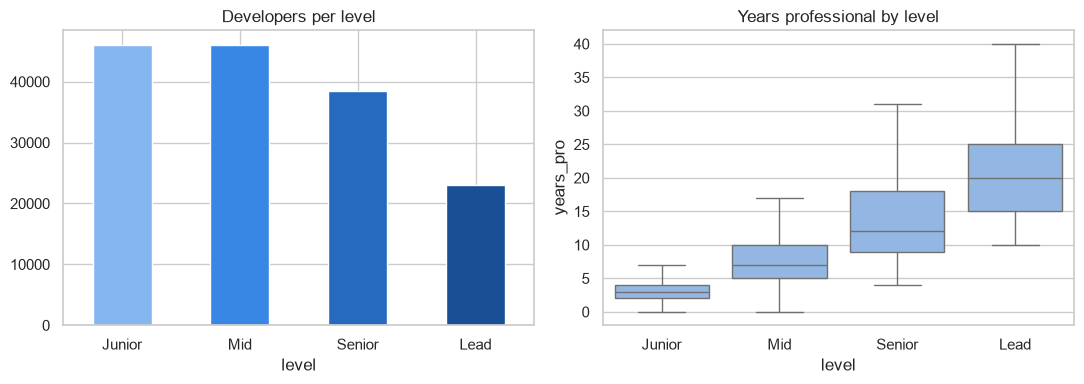

,years_pro,salary_usd,level_score
level,,,
Junior,3.0,36410.0,20.0
Mid,7.0,62820.0,48.0
Senior,12.0,90647.0,68.2
Lead,20.0,139216.0,84.7


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df["level"].value_counts().reindex(LEVELS).plot.bar(ax=axes[0], rot=0, color=["#86b6ef","#3987e5","#256abf","#184f95"], title="Developers per level")
sns.boxplot(data=df, x="level", y="years_pro", order=LEVELS, ax=axes[1], showfliers=False, color="#86b6ef")
axes[1].set_title("Years professional by level")
plt.tight_layout(); plt.savefig(FIG / "levels.png", dpi=120); plt.show()
df.groupby("level")[["years_pro", "salary_usd", "level_score"]].median().reindex(LEVELS).round(1)

## 8. Which skills are more common at higher levels?
This idea powers the **skill gap analysis**.

In [9]:
d = df["skills"].str.get_dummies(sep=";")
top = skills.value_counts().head(30).index
share = d[top].groupby(df["level"]).mean().reindex(LEVELS).T
share["Lead − Junior"] = share["Lead"] - share["Junior"]
share.sort_values("Lead − Junior", ascending=False).head(12).round(2)

level,Junior,Mid,Senior,Lead,Lead − Junior
Amazon Web Services (AWS),0.36,0.45,0.49,0.53,0.17
Kubernetes,0.15,0.22,0.27,0.30,0.16
Bash/Shell,0.29,0.33,0.37,0.42,0.12
Docker,0.51,0.58,0.61,0.62,0.11
Redis,0.17,0.24,0.28,0.28,0.11
Microsoft Azure,0.21,0.25,0.27,0.29,0.07
PostgreSQL,0.42,0.44,0.47,0.48,0.06
Google Cloud,0.18,0.20,0.21,0.23,0.05
Microsoft SQL Server,0.25,0.27,0.28,0.28,0.03
SQL,0.53,0.54,0.55,0.55,0.02
